In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

In [2]:
df = pd.read_csv("bank.csv")

In [3]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
duplicates = df.duplicated()
sum(duplicates)

0

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.shape

(10000, 14)

In [7]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().values.any()

False

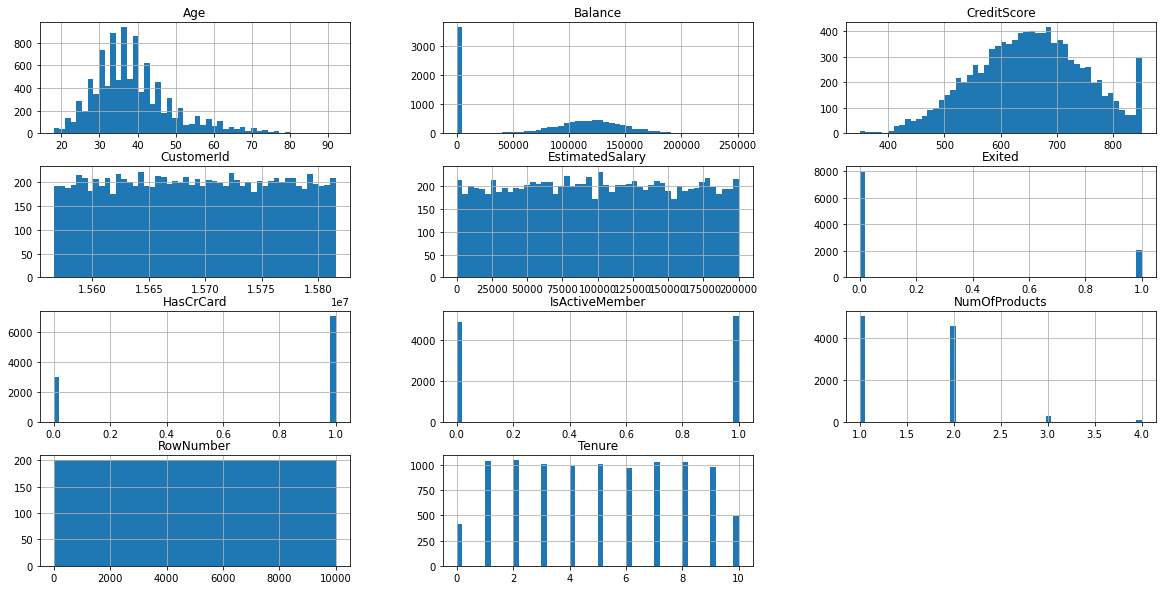

In [11]:
df.hist(figsize=(20,10), bins=50);

In [ ]:
#CustomerID looks unique, Row Number seems useless.

In [10]:
#Dropping columns
df.drop('RowNumber',axis=1,inplace=True)
df.drop('CustomerId',axis=1,inplace=True)
df.drop('Surname',axis=1,inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


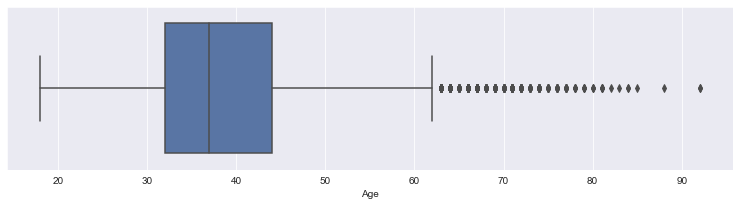

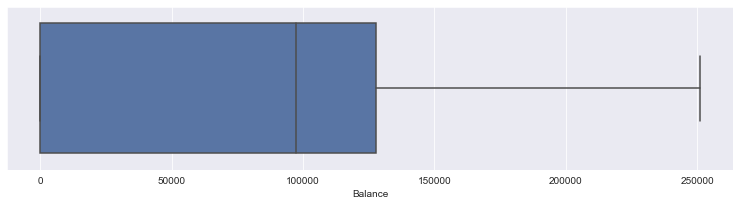

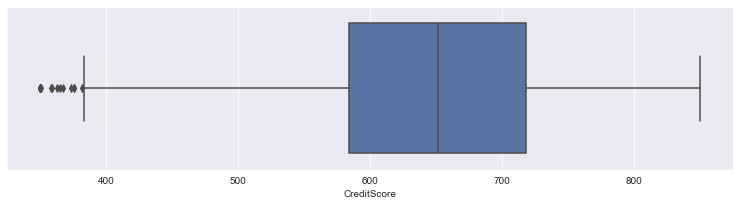

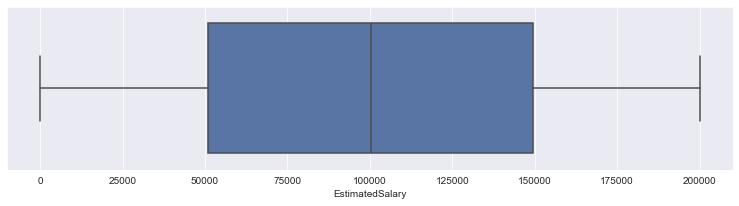

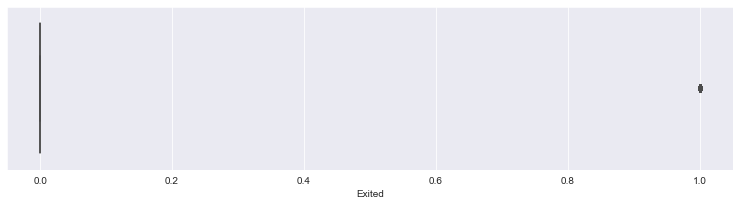

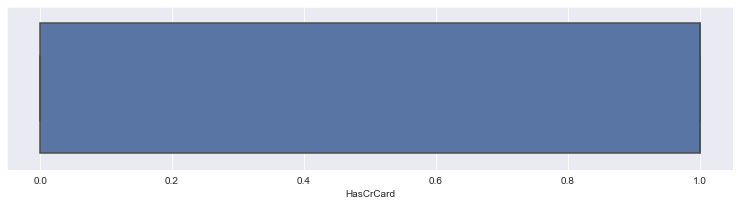

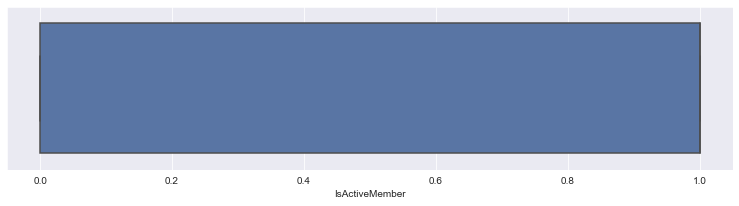

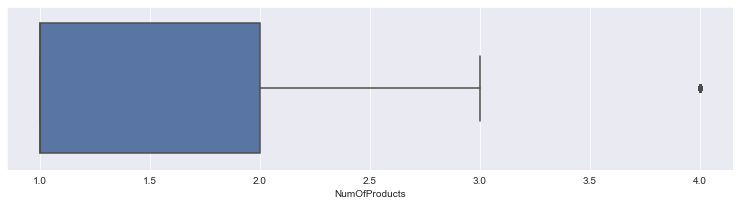

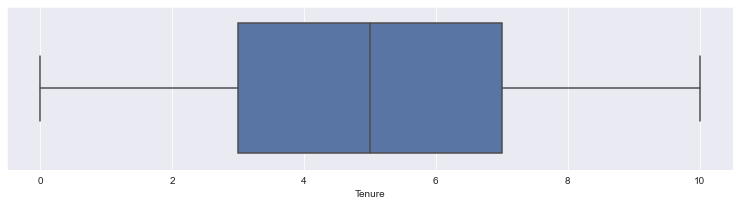

In [11]:
# Outlier detection, Univariate Boxplots
sns.set({'figure.figsize': (13,3)})
def box_plot(frame):
    for i in ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Exited', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Tenure']:
        sns.boxplot(df[i])
        plt.show()
            
box_plot(df)

In [ ]:
#I decided that there are not enough outliers in the set to make removal worthwhile.

# Bivariate Analysis

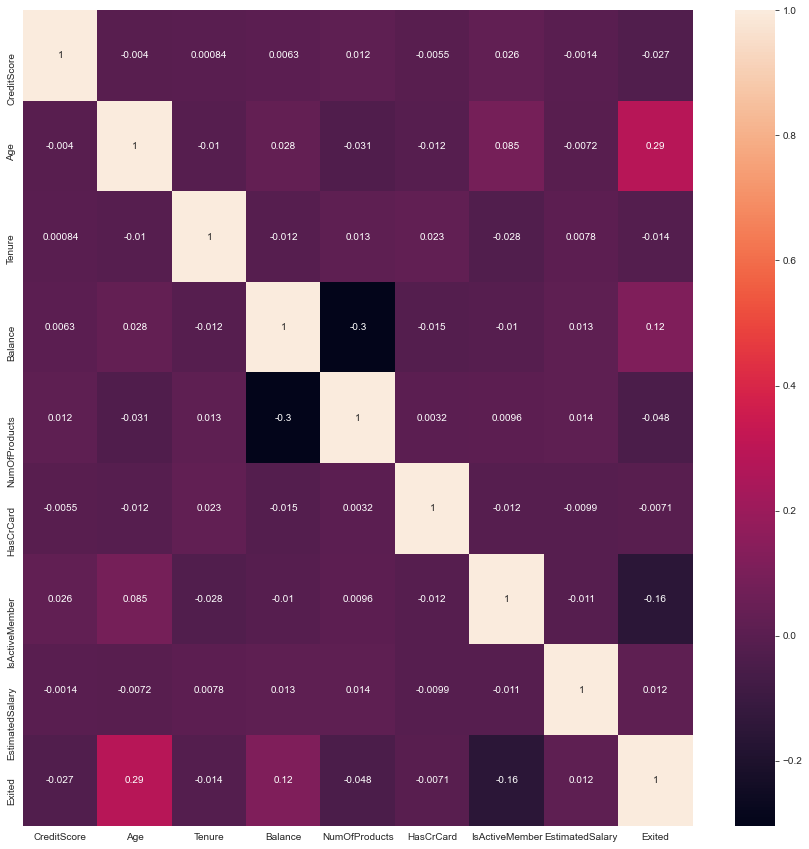

In [15]:
#Heatmap
sns.set({'figure.figsize': (15,15)})
sns.heatmap(df.corr(), annot=True);

In [ ]:
#No real coorelation between features

/Users/cyrusmajidy/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)


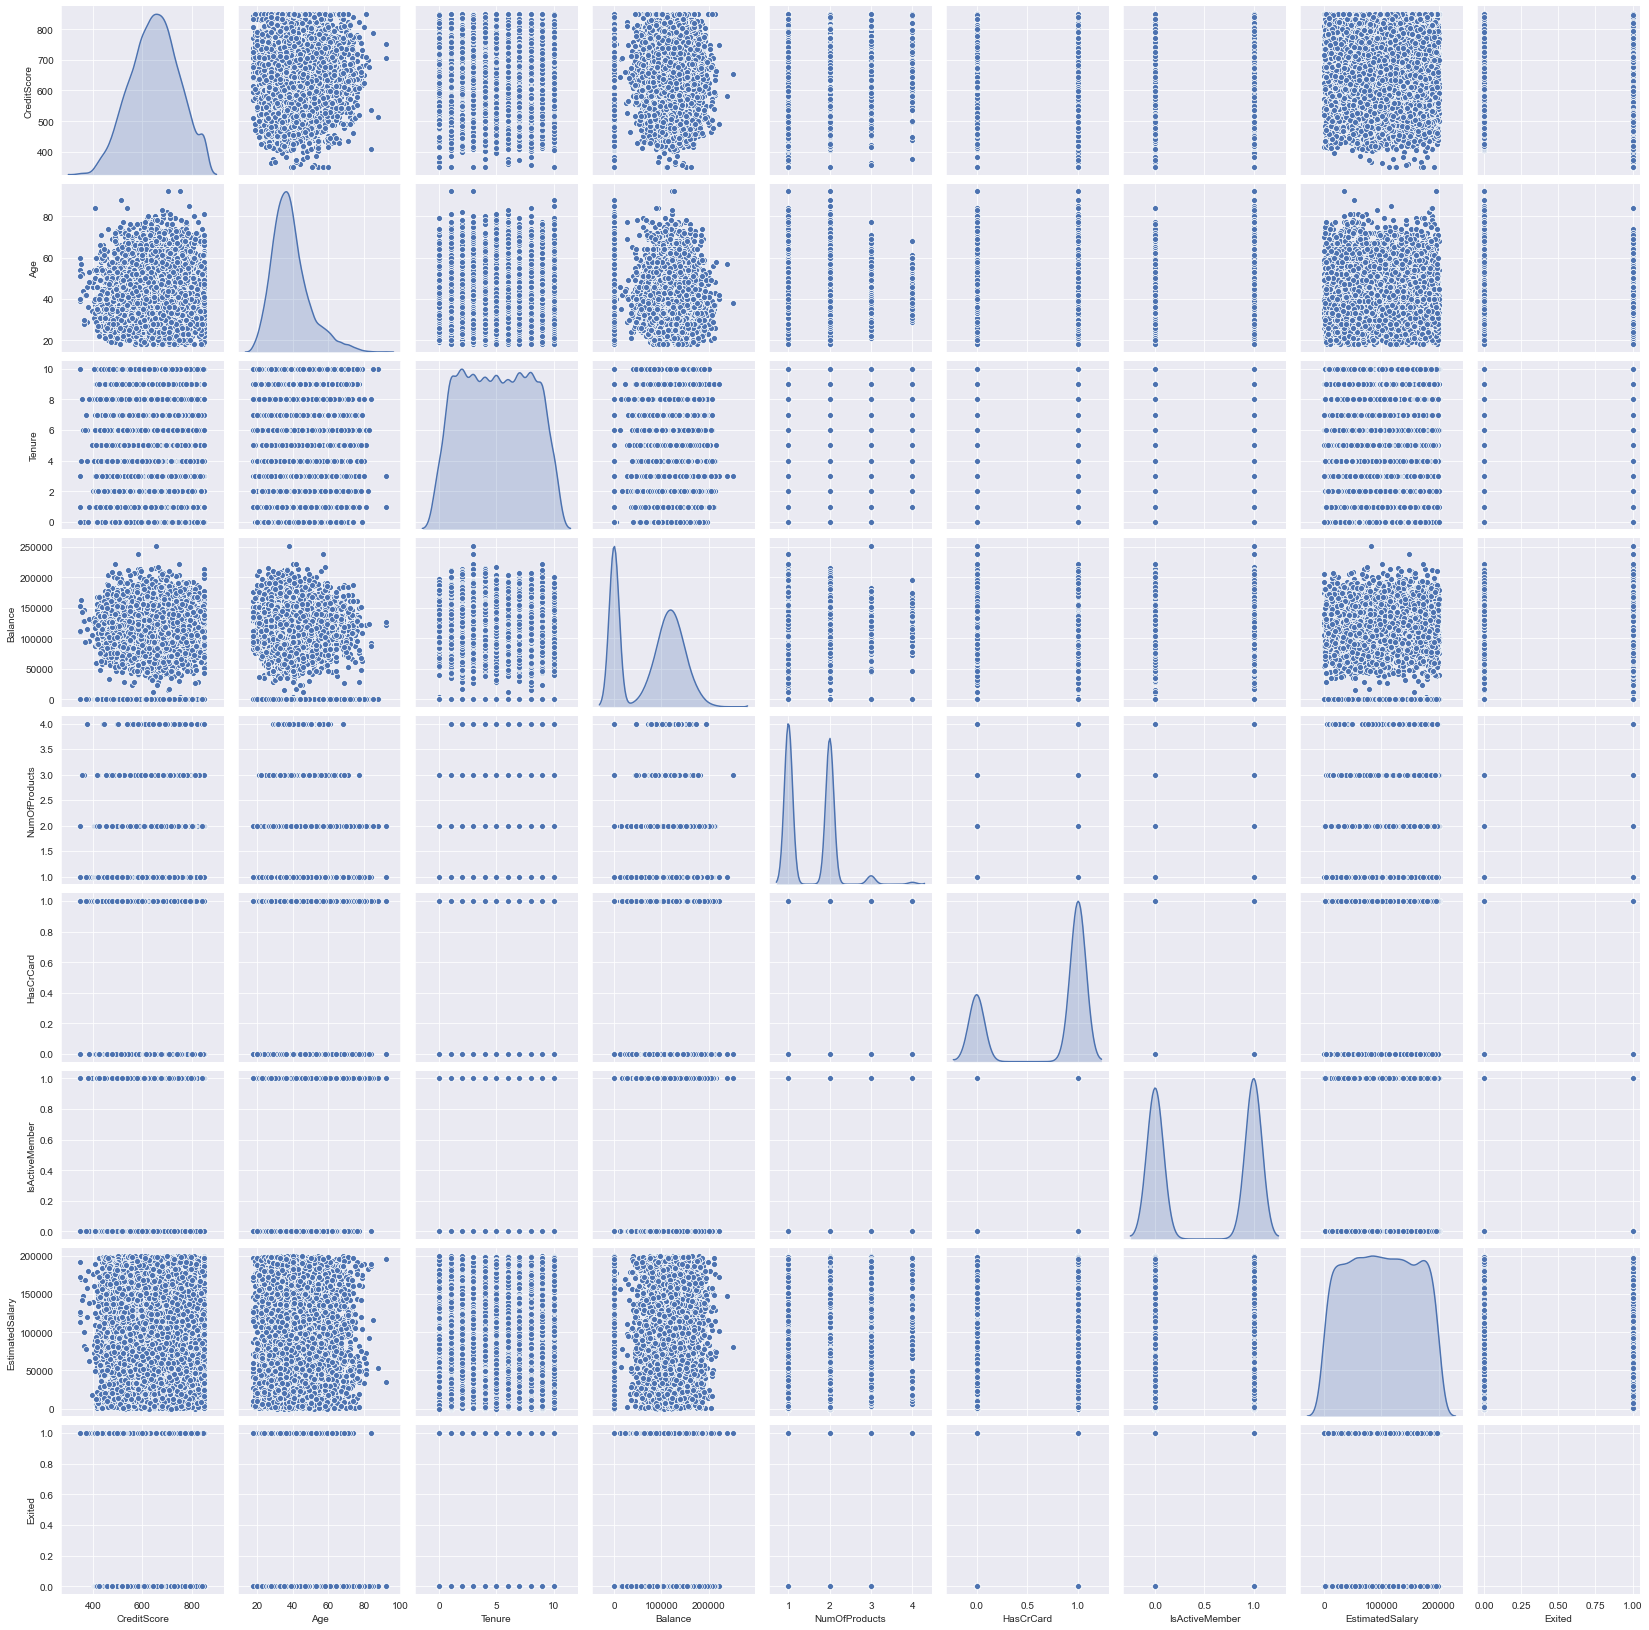

In [16]:
#pairplot
sns.pairplot(df, diag_kind='kde');

In [11]:
df.skew()

CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
Exited             1.471611
dtype: float64

In [12]:
#Encode variables/get dummies
df = pd.get_dummies(df, columns=['Geography','Gender'])
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


In [13]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale

StandardScaler()

In [14]:
df['Age'] = std_scale.fit_transform(df[['Age']])
df['Balance'] = std_scale.fit_transform(df[['Balance']])
df['CreditScore'] = std_scale.fit_transform(df[['CreditScore']])
df['EstimatedSalary'] = std_scale.fit_transform(df[['EstimatedSalary']])
df['NumOfProducts'] = std_scale.fit_transform(df[['NumOfProducts']])
df['Tenure'] = std_scale.fit_transform(df[['Tenure']])

In [15]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,1,0,0,1,0
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,0,0,1,1,0
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,1,0,0,1,0
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,1,0,0,1,0
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,0,0,1,1,0


In [16]:
# Train Test Split
from sklearn.model_selection import train_test_split

#It looks like "Exited" is the variable we are solving for in order to predict if the customer will exit.
x = df.drop('Exited', axis=1)
y = df['Exited']

#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(x, y, test_size=0.3)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=0.5)

In [17]:
print(x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape)

(7000, 13) (1500, 13) (1500, 13) (7000,) (1500,) (1500,)


In [18]:
#Build model

In [19]:
from keras.models import Sequential
from keras.layers import Dense

#Decided to have 32 neurons, 10 input features, 1 neuron for output class.

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(13,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

Using TensorFlow backend.


In [20]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'],)

In [21]:
#Best results
hist = model.fit(x_train, y_train,
          batch_size=32, epochs=100, 
          verbose=1,
          validation_data=(x_val, y_val))

Train on 7000 samples, validate on 1500 samples
Epoch 1/100
7000/7000 [==============================] - 1s 107us/step - loss: 0.5226 - accuracy: 0.7930 - val_loss: 0.4875 - val_accuracy: 0.7987
Epoch 2/100
7000/7000 [==============================] - 0s 50us/step - loss: 0.4743 - accuracy: 0.7951 - val_loss: 0.4566 - val_accuracy: 0.7987
Epoch 3/100
7000/7000 [==============================] - 0s 49us/step - loss: 0.4494 - accuracy: 0.7951 - val_loss: 0.4365 - val_accuracy: 0.7980
Epoch 4/100
7000/7000 [==============================] - 0s 49us/step - loss: 0.4330 - accuracy: 0.7970 - val_loss: 0.4230 - val_accuracy: 0.8060
Epoch 5/100
7000/7000 [==============================] - 0s 49us/step - loss: 0.4219 - accuracy: 0.8061 - val_loss: 0.4136 - val_accuracy: 0.8140
Epoch 6/100
7000/7000 [==============================] - 0s 48us/step - loss: 0.4142 - accuracy: 0.8180 - val_loss: 0.4065 - val_accuracy: 0.8253
Epoch 7/100
7000/7000 [==============================] - 0s 49us/step - los

In [22]:
#To see the accuracy of our test set
model.evaluate(x_test, y_test)[1]

1500/1500 [==============================] - 0s 21us/step


0.846666693687439

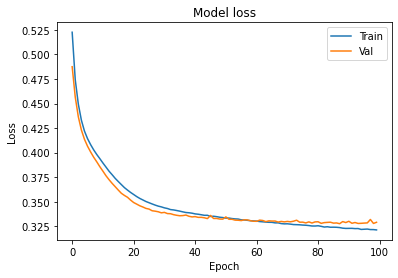

In [23]:
#Visualize the training and validation loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

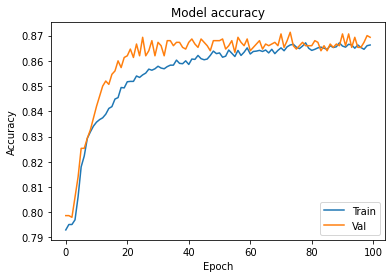

In [24]:
#Visualize the training and validation accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [25]:
#Predict
#I believe threshold is 0.5 by default. I could also use predict_classes()
prediction = model.predict(x_test)

for i in prediction:
    print(i)

[0.5768887]
[0.0082334]
[0.4138107]
[0.05892015]
[0.12314367]
[0.04594892]
[0.33236557]
[0.07334024]
[0.07789806]
[0.4816419]
[0.7867186]
[0.9175111]
[0.5056772]
[0.24216697]
[0.28721613]
[0.02107179]
[0.7896364]
[0.45540923]
[0.00953758]
[0.13188705]
[0.06296515]
[0.00652385]
[0.42111558]
[0.05400583]
[0.05956912]
[0.22101998]
[0.17045507]
[0.02638012]
[0.01770243]
[0.00659961]
[0.5704863]
[0.20080131]
[0.133006]
[0.16366288]
[0.04830343]
[0.04571632]
[0.11517629]
[0.07025331]
[0.01331913]
[0.11162275]
[0.15478909]
[0.02752304]
[0.62798953]
[0.22250772]
[0.68333846]
[0.29963422]
[0.09854472]
[0.00892946]
[0.5136419]
[0.12265289]
[0.05836067]
[0.01444638]
[0.1016466]
[0.8830205]
[0.10175198]
[0.14225787]
[0.1699974]
[0.20299754]
[0.26302844]
[0.3907761]
[0.20665267]
[0.43018603]
[0.03862897]
[0.46728206]
[0.0240576]
[0.268883]
[0.19107437]
[0.05627507]
[0.01068798]
[0.45170936]
[0.36059475]
[0.01181588]
[0.03388804]
[0.8502084]
[0.66077906]
[0.41362774]
[0.17226154]
[0.5113281]
[0.6549

[0.37698832]
[0.19975013]
[0.297196]
[0.16681567]
[0.38927436]
[0.4081933]
[0.50978917]
[0.22479105]
[0.85824925]
[0.5039056]
[0.00876942]
[0.0887669]
[0.07997057]
[0.3239647]
[0.49492916]
[0.3290039]
[0.1456587]
[0.03283876]
[0.00502166]
[0.10903075]
[0.00397453]
[0.02317825]
[0.02049965]
[0.05149058]
[0.28042847]
[0.25176305]
[0.04339874]
[0.00439504]
[0.40426448]
[0.00434873]
[0.00318998]
[0.18046328]
[0.0945721]
[0.3570733]
[0.07945755]
[0.02717382]
[0.63242096]
[0.01739284]
[0.16949695]
[0.01636159]
[0.03515539]
[0.04853797]
[0.04810777]
[0.09795266]
[0.44867405]
[0.2877227]
[0.9576193]
[0.9527526]
[0.65688103]
[0.09566131]
[0.00593129]
[0.04569241]
[0.03779545]
[0.6125182]
[0.4226607]
[0.9567697]
[0.12821296]
[0.0414103]
[0.1294558]
[0.21445999]
[0.429394]
[0.04705185]
[0.03820336]
[0.21516642]
[0.17677489]
[0.01854602]
[0.72398305]
[0.11545688]
[0.28718162]
[0.17560539]
[0.0059889]
[0.00618052]
[0.06727472]
[0.28368574]
[0.37688857]
[0.01775205]
[0.26343852]
[0.02606004]
[0.6065

In [26]:
print(prediction)

[[0.5768887 ]
 [0.0082334 ]
 [0.4138107 ]
 ...
 [0.01978844]
 [0.00998721]
 [0.1517852 ]]


Confusion Matrix:   



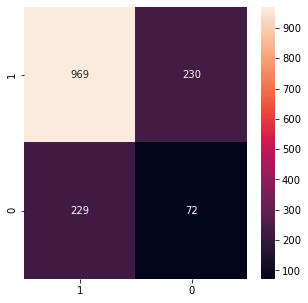

In [27]:
#Confusion matrix
from sklearn import metrics
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:  ", "\n"), 

cm_array = metrics.confusion_matrix(y_test, y_val, labels=[1,0])
cm = np.flip(cm_array) 
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [28]:
#Attempting to Improve the model by tweaking parameters
from keras.layers import Dropout
from keras import regularizers
from keras import layers
from keras import models
from keras import utils
from keras.layers import Flatten
from keras.layers import Activation
from keras.regularizers import l2
from keras.optimizers import SGD
from keras.optimizers import RMSprop
from keras.callbacks import LearningRateScheduler
from keras.callbacks import History
from keras import losses
from sklearn.utils import shuffle

In [29]:
from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier

In [30]:
model = Sequential()
model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(13,)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)))

In [32]:
#Setting the SGD values
epochs=100
learning_rate = 0.1
decay_rate = learning_rate / epochs
momentum = 0.8

sgd = SGD(lr=learning_rate, momentum=momentum, decay=decay_rate, nesterov=False)

In [33]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'],)

In [34]:
hist = model.fit(x_train, y_train,
          batch_size=60, epochs=100, 
          verbose=1,
          validation_data=(x_val, y_val))

Train on 7000 samples, validate on 1500 samples
Epoch 1/100
7000/7000 [==============================] - 1s 147us/step - loss: 1.1419 - accuracy: 0.6687 - val_loss: 1.0255 - val_accuracy: 0.7947
Epoch 2/100
7000/7000 [==============================] - 0s 42us/step - loss: 1.0250 - accuracy: 0.7894 - val_loss: 0.9745 - val_accuracy: 0.7947
Epoch 3/100
7000/7000 [==============================] - 0s 43us/step - loss: 0.9772 - accuracy: 0.7939 - val_loss: 0.9390 - val_accuracy: 0.7947
Epoch 4/100
7000/7000 [==============================] - 0s 42us/step - loss: 0.9469 - accuracy: 0.7953 - val_loss: 0.9094 - val_accuracy: 0.7947
Epoch 5/100
7000/7000 [==============================] - 0s 42us/step - loss: 0.9128 - accuracy: 0.7953 - val_loss: 0.8833 - val_accuracy: 0.7947
Epoch 6/100
7000/7000 [==============================] - 0s 42us/step - loss: 0.8858 - accuracy: 0.7961 - val_loss: 0.8600 - val_accuracy: 0.7947
Epoch 7/100
7000/7000 [==============================] - 0s 42us/step - los

In [35]:
#To see the accuracy of our test set
model.evaluate(x_test, y_test)[1]

1500/1500 [==============================] - 0s 24us/step


0.8299999833106995

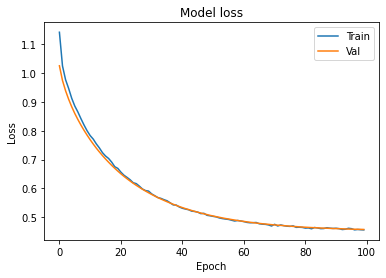

In [36]:
#Visualize the training and validation loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

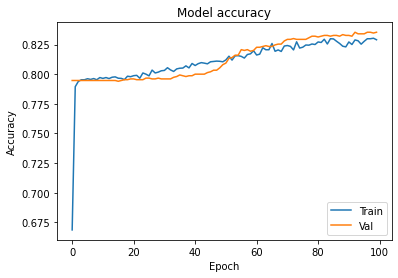

In [37]:
#Visualize the training and validation accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [38]:
#Predict
prediction = model.predict(x_test)

for i in prediction:
    print(i)

[0.376806]
[0.11938933]
[0.08569276]
[0.53247535]
[0.37471235]
[0.11918119]
[0.20336574]
[0.06669286]
[0.5316935]
[0.08192289]
[0.09453335]
[0.11758086]
[0.20053753]
[0.21982688]
[0.1279822]
[0.3895262]
[0.19732332]
[0.38689595]
[0.06742087]
[0.24046662]
[0.05886471]
[0.23074055]
[0.3108655]
[0.1589581]
[0.17067412]
[0.04455432]
[0.13320342]
[0.33297342]
[0.56966037]
[0.12722519]
[0.09053645]
[0.12240764]
[0.1203396]
[0.22114557]
[0.22666323]
[0.35194242]
[0.14720109]
[0.05851161]
[0.16445673]
[0.10976806]
[0.16922808]
[0.19920418]
[0.19794416]
[0.3347751]
[0.3652814]
[0.19134521]
[0.31663063]
[0.17443231]
[0.4545282]
[0.46420705]
[0.5173129]
[0.06354341]
[0.39195198]
[0.09795091]
[0.28081745]
[0.08451158]
[0.21851659]
[0.5597746]
[0.11420995]
[0.13080606]
[0.34320515]
[0.2899052]
[0.07983169]
[0.06427008]
[0.44332972]
[0.14682516]
[0.09347564]
[0.41931525]
[0.43810254]
[0.11348572]
[0.07920033]
[0.06018192]
[0.5349972]
[0.07532027]
[0.122866]
[0.0860284]
[0.0916793]
[0.50435]
[0.07095

[0.06817448]
[0.06477356]
[0.16828069]
[0.44546586]
[0.06016716]
[0.06878883]
[0.07286417]
[0.44977462]
[0.11891419]
[0.07030398]
[0.22297731]
[0.1202296]
[0.36177802]
[0.14353424]
[0.08381802]
[0.127785]
[0.12182602]
[0.3451417]
[0.2750299]
[0.09718183]
[0.06679112]
[0.12429515]
[0.10437134]
[0.10464966]
[0.07866248]
[0.13802144]
[0.28256547]
[0.40711215]
[0.07914767]
[0.12518969]
[0.20199871]
[0.12677759]
[0.23652062]
[0.17719603]
[0.0613341]
[0.22985572]
[0.04715192]
[0.33066368]
[0.21070975]
[0.16004336]
[0.2908532]
[0.10381809]
[0.07791263]
[0.08794802]
[0.11827543]
[0.15827733]
[0.25831226]
[0.05127287]
[0.05786133]
[0.35237575]
[0.16624135]
[0.2115168]
[0.05388224]
[0.10979897]
[0.12143159]
[0.2578203]
[0.49699536]
[0.14115801]
[0.03636932]
[0.66353613]
[0.06366298]
[0.57745194]
[0.06256381]
[0.19714573]
[0.23855111]
[0.23909345]
[0.07074147]
[0.07996163]
[0.06163251]
[0.13517666]
[0.31603333]
[0.09682682]
[0.11865872]
[0.06286719]
[0.11707225]
[0.06571126]
[0.3352338]
[0.080004

In [39]:
print(prediction)

[[0.376806  ]
 [0.11938933]
 [0.08569276]
 ...
 [0.09449849]
 [0.38790786]
 [0.45105678]]


Confusion Matrix:   



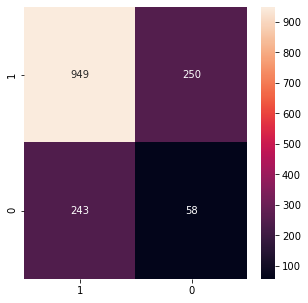

In [40]:
#Confusion matrix
from sklearn import metrics
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:  ", "\n"), 

cm_array = metrics.confusion_matrix(y_test, y_val, labels=[1,0])
cm = np.flip(cm_array) 
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=[1,0], yticklabels=[1,0]);

In [ ]:
#As we can see, the 1st attempt was my best.